# Домашнее задание 2. Градиентный спуск. 10 баллов

В этом домашнем задании вы напишете градиентный спуск для линейной регрессии, а так же посмотрите, как он ведёт себя с разными параметрами и разными функциями потерь.

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

In [1]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — Mean Squared Error:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели, его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов

Для того чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его не нужно. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения градиента (вектор)

In [2]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактоного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`

Он должен вычислять лосс и градиент по формулам наверху

In [3]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        # -- YOUR CODE HERE --
        # Вычислите значение функции потерь при помощи X, y и w и верните его

        # Сначала предсказания Xw
        predictions=X@w
        # Потом разница между нашими предсказаниями и реальными значениями
        errors=predictions-y
        # Теперь к самому MSE
        loss=np.mean(errors**2)

        return loss


    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # -- YOUR CODE HERE --
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

        # Посчитаем общее количество объектов
        n_amount=X.shape[0]
        # Снова предсказания
        predictions=X@w
        # Разница между ними и реальными знчениями
        errors=predictions-y
        # И градиент функционала по формуле для MSE выше
        gradien=(2/n_amount)*(X.T@errors)

        return gradien


Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [4]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^t = w^{t-1} - \eta \nabla_{w} Q(w^{t-1}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше и возвращать
траекторию спуска (список из новых значений весов на каждом шаге)

In [5]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    # -- YOUR CODE HERE --
    # Буду использовать копии, потому что кто-то сказал, что так безопаснее
    # Особенно тут, где зависимость отследить будет сложно

    # Создаём список для хранения весов
    weights=[]
    # И идём с самого начала
    now_w=w_init.copy()

    for i in range(n_iterations):
      # Сохраняем значение веса
      weights.append(now_w.copy())
      # Теперь градиент
      gradient=loss.calc_grad(X,y,now_w)
      # И шагаем дальше по формуле для градиентного спуска выше
      now_w=now_w-lr*gradient

    return weights

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории:

In [6]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [7]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.58917680450253
0.8670644395649652


In [8]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # visualize the level set
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # visualize trajectory
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте не менее четырёх разных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1

Start loss: 425.5892
End loss: 3.7387
Improvment: 113.83x



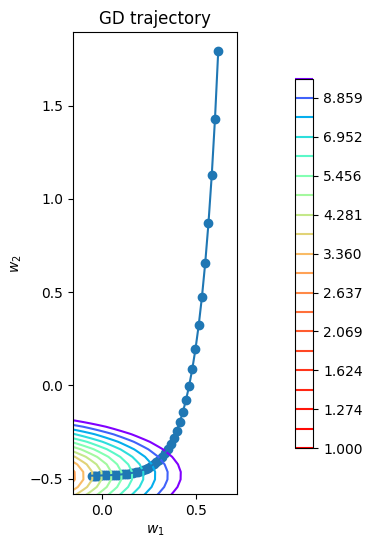

Start loss: 425.5892
End loss: 0.8722
Improvment: 487.95x



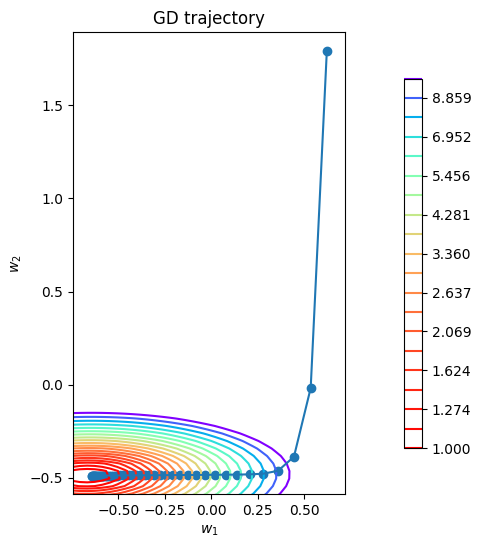

Start loss: 425.5892
End loss: 0.8671
Improvment: 490.84x



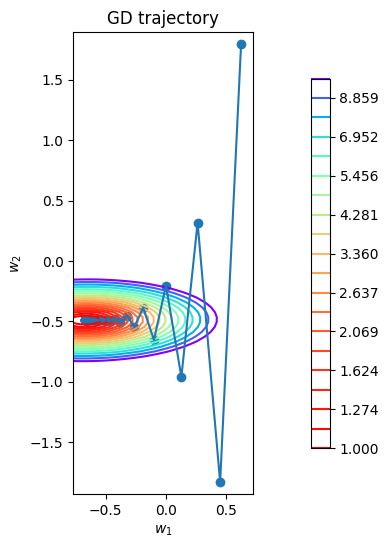

Start loss: 425.5892
End loss: 0.9178
Improvment: 463.71x



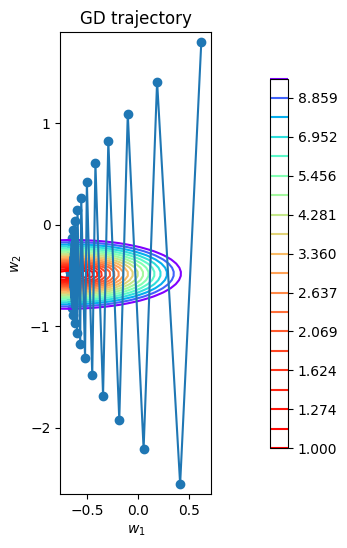

'\n  Анализ по полученным графикам:\n\n  LR=0.001\n    Плавно с маленькими шажками идём к минимуму без колебаний\n    Неэффективно, так как шаг маленький, но надёжно\n\n  LR=0.005\n    Почти такая же плавная, но чуть поувереннее\n    Стабильно движется к минимуму без колебаний\n    Можно сказать идеальный баланс между скоростью и надёжностью\n\n  LR=0.01\n    Самое оптимальное значение для этих данных\n    Быстро уверенными шагами движется к минимуму\n\n  LR=0.012\n    Появляются колебания при приближении к минимуму\n    Сначала такая же быстрая, но потом из-за переборов замедляется\n    Менее стабильно, чем предыдущее значение\n'

In [9]:
# -- YOUR CODE HERE --
# Список изучаемых lr
# Их я находила способом проб и ошибок - для слишком больших график сильно искажён :(
lrs=[0.001,0.005,0.01,0.012]
n_iterations=50

for lr in lrs:
  # Начинаем градиентно спускаться :)
  w_list=gradient_descent(w_init,X,y,loss,lr,n_iterations)

  # Считаем начальные и конечные значения
  start_loss = loss.calc_loss(X, y, w_list[0])
  end_loss = loss.calc_loss(X, y, w_list[-1])

  print(f"Start loss: {start_loss:.4f}")
  print(f"End loss: {end_loss:.4f}")
  print(f"Improvment: {start_loss/end_loss:.2f}x")
  print()

  # Используем plot_gd
  plot_gd(w_list, X, y, loss)

"""
  Анализ по полученным графикам:

  LR=0.001
    Плавно с маленькими шажками идём к минимуму без колебаний
    Неэффективно, так как шаг маленький, но надёжно

  LR=0.005
    Почти такая же плавная, но чуть поувереннее
    Стабильно движется к минимуму без колебаний
    Можно сказать идеальный баланс между скоростью и надёжностью

  LR=0.01
    Самое оптимальное значение для этих данных
    Быстро уверенными шагами движется к минимуму

  LR=0.012
    Появляются колебания при приближении к минимуму
    Сначала такая же быстрая, но потом из-за переборов замедляется
    Менее стабильно, чем предыдущее значение
"""

Теперь реализуем стохастический градиентный спуск

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [10]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    # -- YOUR CODE HERE --
    # Так же использую .copy()

    # Список весов
    weights=[]
    # Аналогично начинаем с начального
    now_w=w_init.copy()
    # Количество объектов
    n_amount=X.shape[0]

    for i in range(n_iterations):
        # Сохраняем текущее значение
        weights.append(now_w.copy())
        # Выбираем случайную часть
        batch_indices = np.random.choice(n_amount, size=batch_size, replace=False)
        batch_x = X[batch_indices]
        batch_y = y[batch_indices]
        # Вычисляем градиент на данной части
        gradient=loss.calc_grad(batch_x,batch_y,now_w)
        # Делаем шажок
        now_w=now_w-lr*gradient

    return weights

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

 -- Learning Rate: 0.001, Batch Size: 5 -- 
Start loss: 425.5892
End loss: 1.4614
Improvment: 291.22x



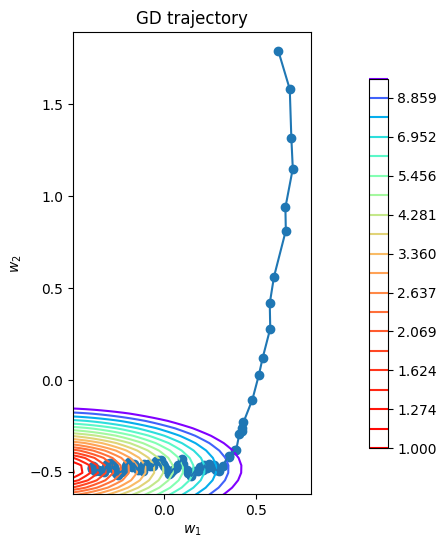

 -- Learning Rate: 0.001, Batch Size: 20 -- 
Start loss: 425.5892
End loss: 1.5377
Improvment: 276.76x



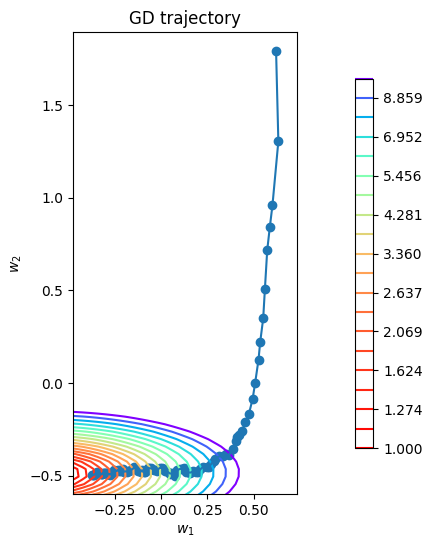

 -- Learning Rate: 0.001, Batch Size: 50 -- 
Start loss: 425.5892
End loss: 1.5720
Improvment: 270.74x



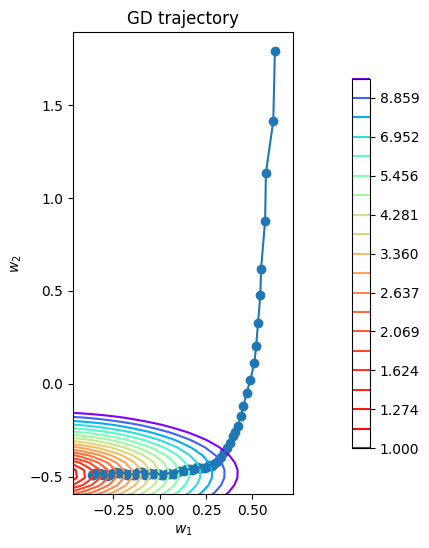

 -- Learning Rate: 0.001, Batch Size: 100 -- 
Start loss: 425.5892
End loss: 1.5012
Improvment: 283.50x



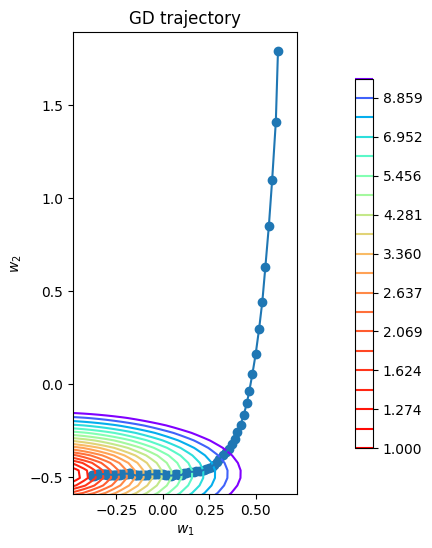

 -- Learning Rate: 0.005, Batch Size: 5 -- 
Start loss: 425.5892
End loss: 0.8704
Improvment: 488.95x



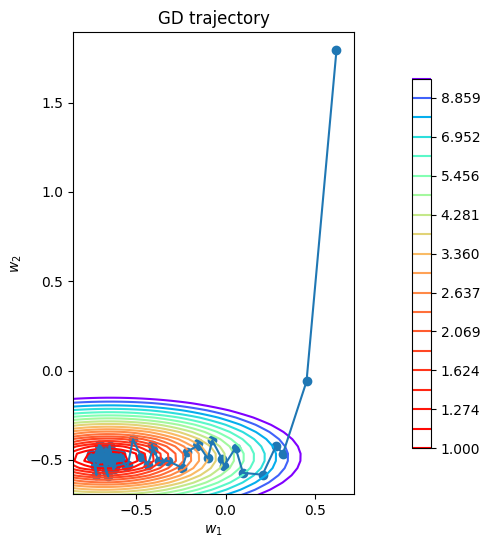

 -- Learning Rate: 0.005, Batch Size: 20 -- 
Start loss: 425.5892
End loss: 0.8767
Improvment: 485.44x



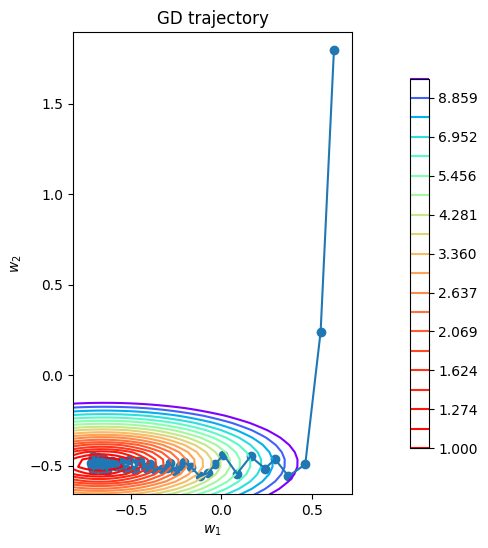

 -- Learning Rate: 0.005, Batch Size: 50 -- 
Start loss: 425.5892
End loss: 0.8731
Improvment: 487.43x



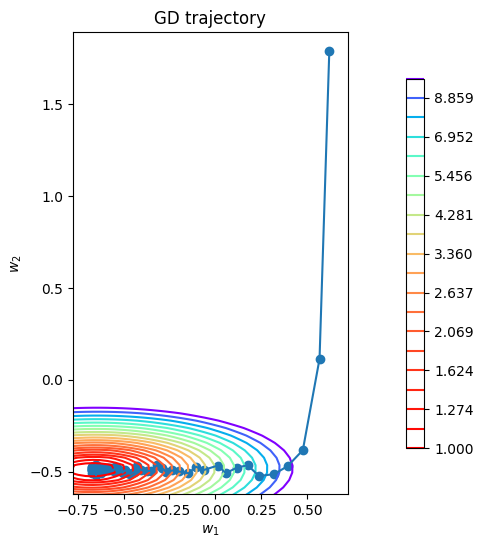

 -- Learning Rate: 0.005, Batch Size: 100 -- 
Start loss: 425.5892
End loss: 0.8685
Improvment: 490.01x



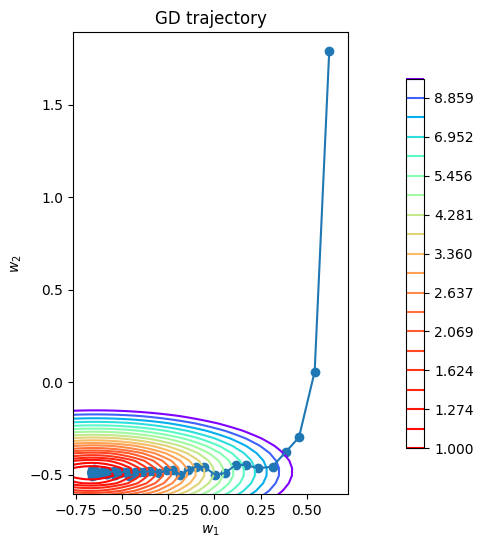

 -- Learning Rate: 0.01, Batch Size: 5 -- 
Start loss: 425.5892
End loss: 0.9118
Improvment: 466.77x



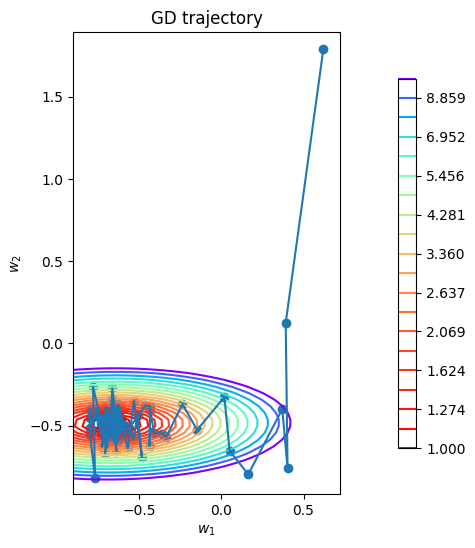

 -- Learning Rate: 0.01, Batch Size: 20 -- 
Start loss: 425.5892
End loss: 0.8903
Improvment: 478.00x



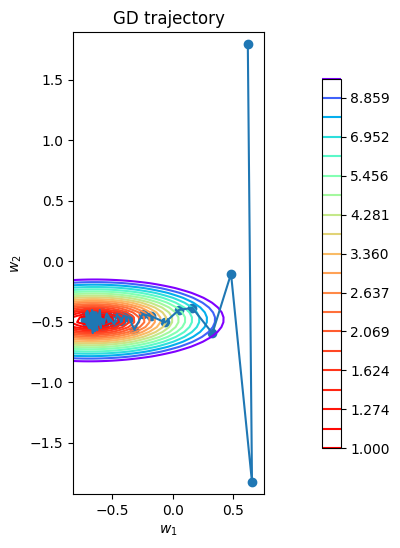

 -- Learning Rate: 0.01, Batch Size: 50 -- 
Start loss: 425.5892
End loss: 0.8939
Improvment: 476.11x



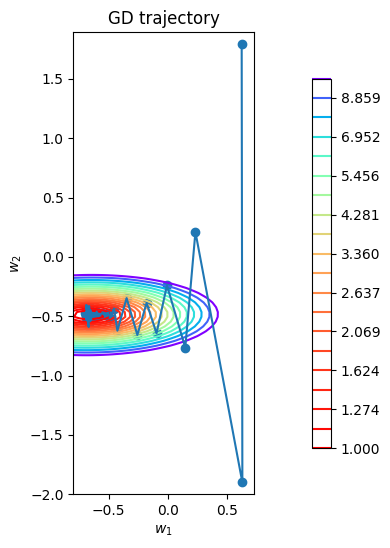

 -- Learning Rate: 0.01, Batch Size: 100 -- 
Start loss: 425.5892
End loss: 0.8683
Improvment: 490.15x



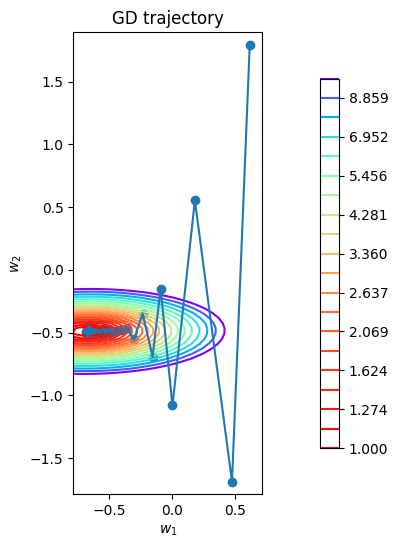

 -- Learning Rate: 0.012, Batch Size: 5 -- 
Start loss: 425.5892
End loss: 13.6632
Improvment: 31.15x



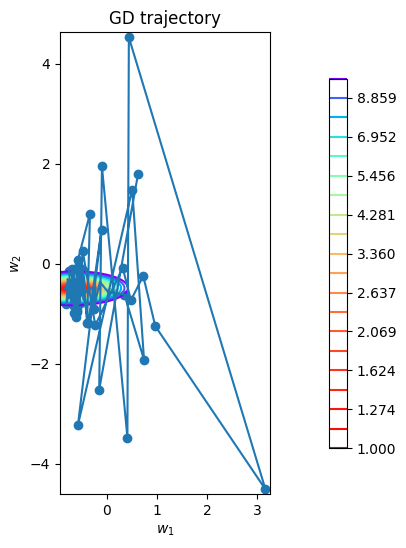

 -- Learning Rate: 0.012, Batch Size: 20 -- 
Start loss: 425.5892
End loss: 1.4655
Improvment: 290.41x



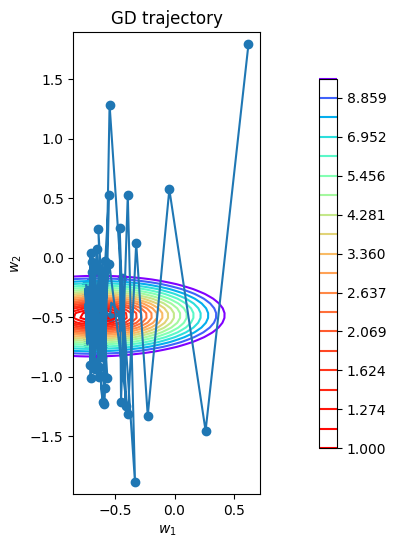

 -- Learning Rate: 0.012, Batch Size: 50 -- 
Start loss: 425.5892
End loss: 1.0569
Improvment: 402.68x



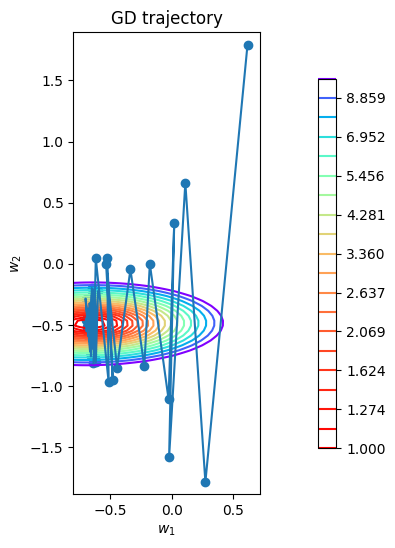

 -- Learning Rate: 0.012, Batch Size: 100 -- 
Start loss: 425.5892
End loss: 0.9143
Improvment: 465.47x



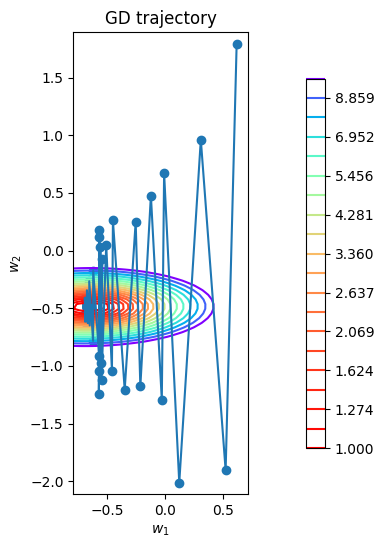

'\n  Анализ по полученным графикам:\n\n  LR=0.001\n    Очень медленная, но надёжно сходится - не для практического применения\n    b_size=5\n      Медленнее всех, немного ломаная, но точно сходится\n    b_size=100\n      Наиболее гладкая траектория приближения\n\n  LR=0.005\n    Опять баланс между скоростью и стабильностью - самый оптимальный\n    b_size=5\n      Немного ломаная, достаточно быстро и хорошо приближается\n    b_size=20\n      Ещё быстрее, шума не так много, стабильность та же\n    b_size=50\n    b_size=100\n      Стабильнее, но скорость меньше\n    \n\n  LR=0.01\n    Максимум для хорошего схождения и стабильности\n    b_size=5\n      Опасные осцилляции\n    b_size=20\n      Менее опасные и быстрее\n    b_size=50\n    b_size=100\n      Почти нет осцилляций и быстро\n    \n\n  LR=0.012\n    Критическое значение\n    b_size=5\n      Вообще очень опасные расхождения и осцилляции\n    b_size=20\n      Погранично - не всегда работает\n    b_size=50\n    b_size=100\n      Работ

In [11]:
# -- YOUR CODE HERE --
lrs=[0.001,0.005,0.01,0.012]
b_sizes=[5,20,50,100]
n_iterations=100

for lr in lrs:
  for b_size in b_sizes:
    print(f" -- Learning Rate: {lr}, Batch Size: {b_size} -- ")

    # Стохастически спускаемся
    w_list=stochastic_gradient_descent(w_init, X, y, loss, lr, b_size, n_iterations)
    # Вычисляем так же начальные и конечные значения
    start_loss = loss.calc_loss(X, y, w_list[0])
    end_loss = loss.calc_loss(X, y, w_list[-1])

    print(f"Start loss: {start_loss:.4f}")
    print(f"End loss: {end_loss:.4f}")
    print(f"Improvment: {start_loss/end_loss:.2f}x")
    print()

    plot_gd(w_list,X,y,loss)

"""
  Анализ по полученным графикам:

  LR=0.001
    Очень медленная, но надёжно сходится - не для практического применения
    b_size=5
      Медленнее всех, немного ломаная, но точно сходится
    b_size=100
      Наиболее гладкая траектория приближения

  LR=0.005
    Опять баланс между скоростью и стабильностью - самый оптимальный
    b_size=5
      Немного ломаная, достаточно быстро и хорошо приближается
    b_size=20
      Ещё быстрее, шума не так много, стабильность та же
    b_size=50
    b_size=100
      Стабильнее, но скорость меньше


  LR=0.01
    Максимум для хорошего схождения и стабильности
    b_size=5
      Опасные осцилляции
    b_size=20
      Менее опасные и быстрее
    b_size=50
    b_size=100
      Почти нет осцилляций и быстро


  LR=0.012
    Критическое значение
    b_size=5
      Вообще очень опасные расхождения и осцилляции
    b_size=20
      Погранично - не всегда работает
    b_size=50
    b_size=100
      Работает лучше всего, но опять же не всегда!

  В общем, чем больше b_size, тем и больше lr взять можно
  Больше b_size, тем больше стабильность, но меньше скорость
  Но благодаря этому можно редактировать скорость и результаты по тому, что требуется на практике

"""

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы более точнее этого минимума достичь и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [12]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float -- значение степени в формуле затухания длины шага
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    # -- YOUR CODE HERE --
    # Снова веса и начало то же саоме
    weights=[]
    now_w=w_init.copy()
    n_amount=X.shape[0]
    # Параметр по условию
    s0=1

    for t in range(n_iterations):
        # То же самое
        weights.append(now_w.copy())
        # Вычисляем lr по формуле
        now_lr=lr*(s0/(s0+t))**p

        # Части из кода выше
        batch_indices = np.random.choice(n_objects, size=batch_size, replace=False)
        batch_x = X[batch_indices]
        batch_y = y[batch_indices]

        # Теперь градиент и шагаем дальше
        gradient=loss.calc_grad(batch_x,batch_y,now_w)
        now_w=now_w-now_lr*gradient
    return weights


**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска

 -- Параметр p: 0.1 -- 
Start loss: 425.5892
End loss: 0.8738
Improvment: 487.04x



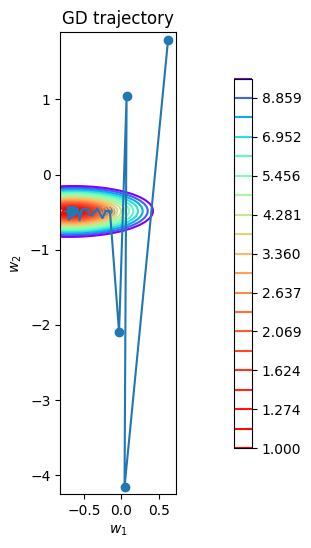

 -- Параметр p: 0.3 -- 
Start loss: 425.5892
End loss: 0.8940
Improvment: 476.05x



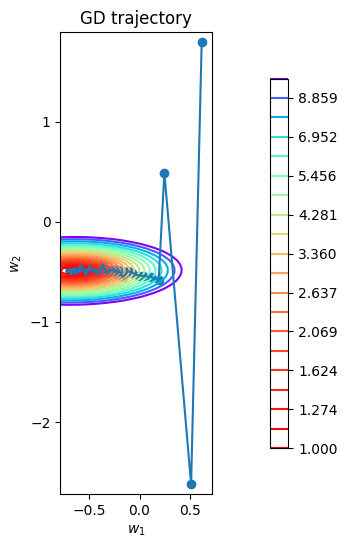

 -- Параметр p: 0.5 -- 
Start loss: 425.5892
End loss: 0.9008
Improvment: 472.44x



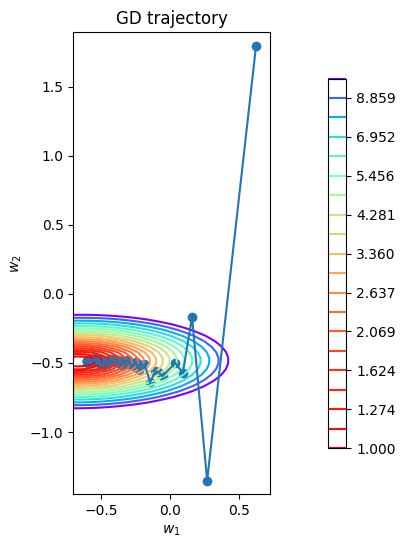

 -- Параметр p: 1.0 -- 
Start loss: 425.5892
End loss: 3.3596
Improvment: 126.68x



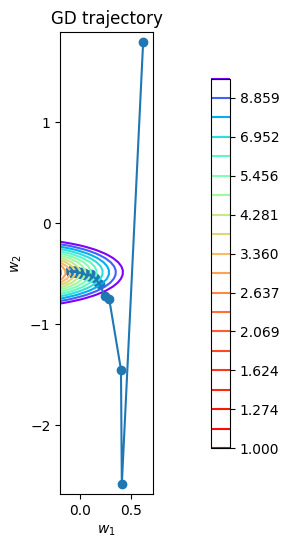

'\n  Анализ влияния p:\n    p=0.1\n      Очень похожа на спуск с постоянным lr\n      Высока скорость, но осциллирует у минимума\n    p=0.3\n      Быстро приближается к минимуму, тонкая настройка в конце\n      И точно, и быстро, но как-то рано он замедлился -_-\n    p=0.5\n      Медленно, но очень точно сходится к минимуму\n    p=1.0\n      Сначала быстрые пару шагов, потом очень медленно подходит к минимум\n      Точно и стабильно, но из-за скорости может остановится далеко от минимума\n\n    В целом, чем больше p, тем больше точность и меньше скорость, и наоборот\n'

In [13]:
# -- YOUR CODE HERE --
ps=[0.1,0.3,0.5,1.0]
lr=0.01
b_size=10
n_iterations=100

for p in ps:
  print(f" -- Параметр p: {p} -- ")
  # Спукаемся, считаем метрики и рисуем - всё по базе
  w_list=stochastic_gradient_descent(w_init,X,y,loss,lr,b_size,p,n_iterations)
  start_loss = loss.calc_loss(X, y, w_list[0])
  end_loss = loss.calc_loss(X, y, w_list[-1])

  print(f"Start loss: {start_loss:.4f}")
  print(f"End loss: {end_loss:.4f}")
  print(f"Improvment: {start_loss/end_loss:.2f}x")
  print()

  plot_gd(w_list,X,y,loss)

"""
  Анализ влияния p:
    p=0.1
      Очень похожа на спуск с постоянным lr
      Высока скорость, но осциллирует у минимума
    p=0.3
      Быстро приближается к минимуму, тонкая настройка в конце
      И точно, и быстро, но как-то рано он замедлился -_-
    p=0.5
      Медленно, но очень точно сходится к минимуму
    p=1.0
      Сначала быстрые пару шагов, потом очень медленно подходит к минимум
      Точно и стабильно, но из-за скорости может остановится далеко от минимума

    В целом, чем больше p, тем больше точность и меньше скорость, и наоборот
"""

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

GD Start loss:425.5892, End loss:0.8671
SGD Start loss:425.5892, End loss:0.9033
GD Improvement:490.84x
SGD Improvement:471.16x


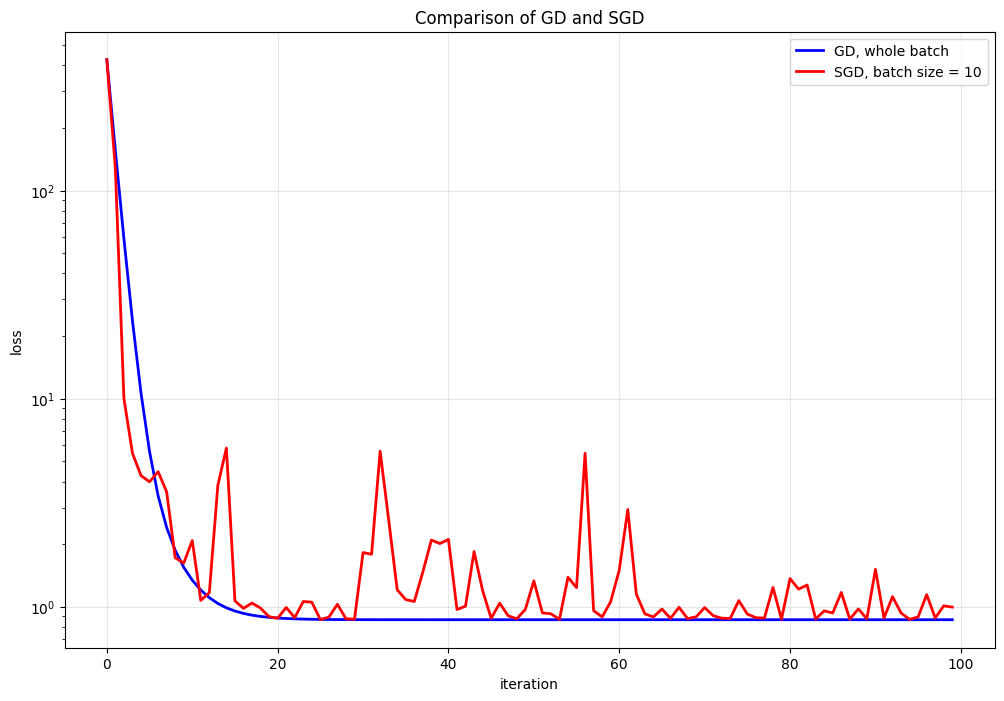

'\n  Выводы:\n    На графике можно увидеть, что SGD сходится гораздо быстрее в самом начале\n    Однако потом траектория становится очень осциллированной и точность не совсем достигается\n    Скорее всего это из-за b_size=10 - слишком маленький\n    GD стартует плавно, но медленно и верно достигает лучшего решения\n'

In [14]:
# -- YOUR CODE HERE --
# Параметры для сравнения
lr=0.01
n_iterations=200
b_size=10

# Значения для обычного градиентного спуска
gd_weights=gradient_descent(w_init,X,y,loss,lr,n_iterations)
gd_losses=[loss.calc_loss(X,y,w) for w in gd_weights]

# Теперь значения для стохастического градиентного спуска с заданными параметрами
sgd_weights=stochastic_gradient_descent(w_init,X,y,loss,lr,b_size,p=0,n_iterations=n_iterations)
sgd_losses=[loss.calc_loss(X,y,w) for w in sgd_weights]

# Немного метрик для большего понимания
print(f"GD Start loss:{gd_losses[0]:.4f}, End loss:{gd_losses[-1]:.4f}")
print(f"SGD Start loss:{sgd_losses[0]:.4f}, End loss:{sgd_losses[-1]:.4f}")
print(f"GD Improvement:{gd_losses[0]/gd_losses[-1]:.2f}x")
print(f"SGD Improvement:{sgd_losses[0]/sgd_losses[-1]:.2f}x")

# Теперь к самому графику
plt.figure(figsize=(12,8))

plt.plot(gd_losses[:100],label="GD, whole batch",linewidth=2,color="blue")
plt.plot(sgd_losses[:100],label="SGD, batch size = 10",linewidth=2,color="red")
plt.title("Comparison of GD and SGD")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

"""
  Выводы:
    На графике можно увидеть, что SGD сходится гораздо быстрее в самом начале
    Однако потом траектория становится очень осциллированной и точность не совсем достигается
    Скорее всего это из-за b_size=10 - слишком маленький
    GD стартует плавно, но медленно и верно достигает лучшего решения
"""

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`

В методе `predict` мы будем применять нашу регрессию к датасету,

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [15]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1,n_iter:int=1000) -> None:
        self.loss = loss
        self.lr = lr
        self.n_iter=n_iter

    def _add_bias(self,X:np.ndarray) -> np.ndarray:
      # Добавляем столбец из единиц для константного признака
      # Решила вынести его в отдельную функцию
      return np.hstack([X,np.ones((X.shape[0],1))])

    def fit(self, X: np.ndarray, y: np.ndarray, verbose: bool=False) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        # X = np.hstack([X, np.ones([X.shape[0], 1])])
        X_with_bias=self._add_bias(X)

        # -- YOUR CODE HERE --
        # Инициализируем веса в w_init
        n_features_with_bias=X_with_bias.shape[1]
        self.w_init=np.random.normal(0,0.1,n_features_with_bias)

        # Градиентно спускаемся
        weights=gradient_descent(
            w_init=self.w_init,
            X=X_with_bias,
            y=y,
            loss=self.loss,
            lr=self.lr,
            n_iterations=self.n_iter
        )
        # Сохраняяем
        self.w=weights[-1]
        self.weights=weights
        # Метрика конечного
        self.end_loss=self.loss.calc_loss(X_with_bias,y,self.w)

        if verbose:
          start_loss=self.loss.calc_loss(X_with_bias,y,self.w_init)
          print("Done!")
          print(f"Start loss: {start_loss:.4f}")
          print(f"End loss: {self.end_loss:.4f}")
          print(f"Improvement: {start_loss/self.end_loss:.2f}x")

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        #X = np.hstack([X, np.ones([X.shape[0], 1])])
        X_with_bias=self._add_bias(X)

        # -- YOUR CODE HERE --
        return X_with_bias@self.w

    # Функция потерь на новых данных
    def score(self,X:np.ndarray,y:np.ndarray) -> float:
        X_with_bias=self._add_bias(X)

        return self.loss.calc_loss(X_with_bias,y,self.w)


Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [16]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [17]:
import pandas as pd

X_raw = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data",
    header=None,
    na_values=["?"],
)
X_raw.head()
X_raw = X_raw[~X_raw[25].isna()].reset_index()

In [18]:
y = X_raw[25]
X_raw = X_raw.drop(25, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [19]:
# -- YOUR CODE HERE --
from sklearn.model_selection import train_test_split

# Делим признаки
num_columns=[]
categ_columns=[]

for col in X_raw.columns:
  if pd.api.types.is_numeric_dtype(X_raw[col]):
    num_columns.append(col)
  else:
    categ_columns.append(col)

# Делим на обучающую и тестовую выборку
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# Функция предобработки
def preprocess(X_train, X_test):
  X_train_p=X_train.copy()
  X_test_p=X_test.copy()

  # Сначала проходимся по числовым признакам
  for col in num_columns:
    # Заполняем пропуски медианой
    median_val=X_train_p[col].median()
    X_train_p[col]=X_train_p[col].fillna(median_val)
    X_test_p[col]=X_test_p[col].fillna(median_val)

    # Нормализация
    mean_val=X_train_p[col].mean()
    std_val=X_train_p[col].std()
    X_train_p[col]=(X_train_p[col]-mean_val)/std_val
    X_test_p[col]=(X_test_p[col]-mean_val)/std_val

  # dummy для категориальных
  all_dum_train=pd.DataFrame()
  all_dum_test=pd.DataFrame()


  # Потом по категориальным - one-hot coding
  X_train_p=pd.get_dummies(X_train_p,columns=categ_columns)
  X_test_p=pd.get_dummies(X_test_p,columns=categ_columns)

  # Выравниваем
  missing_cols = set(X_train_p.columns) - set(X_test_p.columns)
  for col in missing_cols:
      X_test_p[col]=0

  # Проверим, что порядок в порядке
  X_test_p=X_test_p[X_train_p.columns]

  return X_train_p.values, X_test_p.values

X_train_proc,X_test_proc=preprocess(X_train, X_test)
y_train=y_train.values.astype(float)
y_test=y_test.values.astype(float)

**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [20]:
# -- YOUR CODE HERE --
lin_model=LinearRegression(loss=MSELoss(),lr=0.01,n_iter=1000)

# Обучаем
lin_model.fit(X_train_proc,y_train,verbose=True)

print(f"Amount: {X_train_proc.shape[1]}")

# Воспользуемся функцией предсказания
print("\n -- PREDICTIONS --")
y_train_pred = lin_model.predict(X_train_proc)
y_test_pred = lin_model.predict(X_test_proc)

print(f"Predictions on train: {y_train_pred.shape}")
print(f"Predictions on test: {y_test_pred.shape}")

Done!
Start loss: 203726517.5045
End loss: 3521474.1959
Improvement: 57.85x
Amount: 75

 -- PREDICTIONS --
Predictions on train: (160,)
Predictions on test: (41,)


**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [21]:
from sklearn.metrics import mean_squared_error

# -- YOUR CODE HERE --
mse_train=mean_squared_error(y_train,y_train_pred)
mse_test=mean_squared_error(y_test,y_test_pred)

print(" -- MSE -- ")
print(f"MSE on train: {mse_train:.4f}")
print(f"MSE on test: {mse_test:.4f}")

 -- MSE -- 
MSE on train: 3521474.1959
MSE on test: 14804366.3361


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`

Он должен вычислять лосс и градиент по формулам наверху

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`

In [22]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        # -- YOUR CODE HERE --
        # Вычислите значение функции потерь при помощи X, y и w и верните его

        # Сначала основа
        preds=X@w
        errors=preds-y
        mse_loss=np.mean(errors**2)

        # Убираем bias и считаем регуляризацию
        weights_no_bias=w[:-1]
        l2_reg=self.coef*np.sum(weights_no_bias**2)

        full_loss=mse_loss+l2_reg

        return full_loss


    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # -- YOUR CODE HERE --
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

        n_amount=X.shape[0]

        # Снова основа
        preds=X@w
        errors=preds-y
        mse_grad=(2/n_amount)*(X.T@errors)

        # Убираем bias и считаем регуляризацию
        l2_grad=2*self.coef*w.copy()
        # Зануляем, как и советовали
        l2_grad[-1]=0

        full_grad=mse_grad+l2_grad

        return full_grad


Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [23]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [24]:
# -- YOUR CODE HERE --
print(" -- БЕЗ РЕГУЛЯРИЗАЦИИ -- ")
b_model= LinearRegression(loss=MSEL2Loss(),lr=0.01,n_iter=1000)
b_model.fit(X_train_proc,y_train,verbose=True)


y_train_pred_b=b_model.predict(X_train_proc)
y_test_pred_b=b_model.predict(X_test_proc)

mse_train_b=mean_squared_error(y_train,y_train_pred_b)
mse_test_b=mean_squared_error(y_test,y_test_pred_b)

print(f"\nMSE train: {mse_train_b:.4f}")
print(f"MSE test:  {mse_test_b:.4f}")
print(f"RElation test/train: {mse_test_b/mse_train_b:.2f}x")


coefs=[0.0001, 0.00015, 0.0005, 0.001]
best_coef=None
best_test_loss=float('inf')
best_model=None
results=[]

for coef in coefs:
    print(f"\n --- Коэффициент регуляризации: {coef} --- ")
    # Создаем модель с L2 регуляризацией
    l2_model=LinearRegression(loss=MSEL2Loss(coef=coef),lr=0.01,n_iter=1000)
    l2_model.fit(X_train_proc,y_train,verbose=False)

    # Предсказания и оценка
    y_train_pred_l2=l2_model.predict(X_train_proc)
    y_test_pred_l2=l2_model.predict(X_test_proc)

    mse_train_l2=mean_squared_error(y_train,y_train_pred_l2)
    mse_test_l2=mean_squared_error(y_test,y_test_pred_l2)
    relation=mse_test_l2/mse_train_l2

    results.append({
        'coef':coef,
        'mse_train':mse_train_l2,
        'mse_test':mse_test_l2,
        'relation':relation,
        'model':l2_model
    })

    print(f"MSE train: {mse_train_l2:.4f}")
    print(f"MSE test:  {mse_test_l2:.4f}")
    print(f"RElation test/train: {relation:.2f}x")

    # Сохраняем лучшую модель
    if mse_test_l2<best_test_loss:
        best_test_loss=mse_test_l2
        best_coef=coef
        best_model=l2_model

print(f"\n --- ЛУЧШИЙ РЕЗУЛЬТАТ: --- ")
print(f"Коэффициент регуляризации: {best_coef}")
print(f"MSE test: {best_test_loss:.4f}")

"""
  Регуляризция улучшила MSE test - качество модели выросло
  И relation снизилось - переобучения меньше
  А ещё чем меньше коэффициент регуляризации, тем лучше, но я остановилась на 0.0001
"""


 -- БЕЗ РЕГУЛЯРИЗАЦИИ -- 
Done!
Start loss: 203715686.4803
End loss: 13541078.6896
Improvement: 15.04x

MSE train: 8375302.9819
MSE test:  38641154.1930
RElation test/train: 4.61x

 --- Коэффициент регуляризации: 0.0001 --- 
MSE train: 3522732.0267
MSE test:  14812494.2858
RElation test/train: 4.20x

 --- Коэффициент регуляризации: 0.00015 --- 
MSE train: 3523372.6954
MSE test:  14816896.3218
RElation test/train: 4.21x

 --- Коэффициент регуляризации: 0.0005 --- 
MSE train: 3527933.5081
MSE test:  14846470.2516
RElation test/train: 4.21x

 --- Коэффициент регуляризации: 0.001 --- 
MSE train: 3534400.4910
MSE test:  14889201.5837
RElation test/train: 4.21x

 --- ЛУЧШИЙ РЕЗУЛЬТАТ: --- 
Коэффициент регуляризации: 0.0001
MSE test: 14812494.2858


'\n  Регуляризция улучшила MSE test - качество модели выросло\n  И relation снизилось - переобучения меньше\n  А ещё чем меньше коэффициент регуляризации, тем лучше, но я остановилась на 0.0001\n'

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`

Он должен вычислять лосс и градиент по формулам наверху

In [25]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        # -- YOUR CODE HERE --
        # Вычислите значение функции потерь при помощи X, y и w и верните его

        # Снова ошибки
        preds=X@w
        errors=preds-y

        # К Huber Loss'у
        losses=np.zeros_like(errors)

        # Теперь к разным случаям
        # 1 - квадратичная
        mask_1=np.abs(errors)<=self.eps
        losses[mask_1]=0.5*(errors[mask_1]**2)
        # 2 - не квадратичная
        mask_2=~mask_1
        losses[mask_2]=self.eps*(np.abs(errors[mask_2]))-0.5*self.eps

        # Среднее
        return np.mean(losses)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # -- YOUR CODE HERE --
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        n_amount=X.shape[0]

        # Снова мы здесь в ошибках
        preds=X@w
        errors=preds-y

        # Градиент частичками
        grad=np.zeros_like(errors)

        # И случаи
        # 1 - без sign
        mask_1=np.abs(errors)<=self.eps
        grad[mask_1]=errors[mask_1]
        # 2 - с sign
        mask_2=~mask_1
        grad[mask_2]=self.eps*np.sign(errors[mask_2])

        # Теперь по формуле полный градиент
        full_grad=(1/n_amount)*(X.T@grad)

        return full_grad

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [125]:
# -- YOUR CODE HERE --
print(" -- СРАВНЕНИЕ HUBERLOSS И MSELOSS -- ")
print(" -- MSELOSS -- ")

mse_model=LinearRegression(loss=MSELoss(),lr=0.01,n_iter=1000)
mse_model.fit(X_train_proc,y_train,verbose=True)

y_train_pred_mse=mse_model.predict(X_train_proc)
y_test_pred_mse=mse_model.predict(X_test_proc)

mse_train_mse=mean_squared_error(y_train,y_train_pred_mse)
mse_test_mse=mean_squared_error(y_test,y_test_pred_mse)

print(f"MSE train: {mse_train_mse:.4f}")
print(f"MSE test:  {mse_test_mse:.4f}")
print(f"Relation test/train MSE: {mse_test_mse/mse_train_mse:.2f}x")

print("\n -- HUBERLOSS -- ")

# Значения eps пришлось так же потыкать, как и коэффициенты регуляризации
eps_values=[10000.0, 15000.0, 20000.0, 50000.0, 100000.0, 1000000.0]
best_eps=None
best_test_mse=float('inf')
best_huber_model=None
huber_results=[]

for eps in eps_values:
    print(f"\n-- eps={eps} --")

    # Создаем модель с HuberLoss
    huber_model=LinearRegression(loss=HuberLoss(eps=eps),lr=0.01,n_iter=1000)
    huber_model.fit(X_train_proc,y_train,verbose=False)

    # Те же самые метрики
    y_train_pred_huber=huber_model.predict(X_train_proc)
    y_test_pred_huber=huber_model.predict(X_test_proc)

    mse_train_huber=mean_squared_error(y_train,y_train_pred_huber)
    mse_test_huber=mean_squared_error(y_test,y_test_pred_huber)

    relation=mse_test_huber/mse_train_huber

    huber_results.append({
        'eps':eps,
        'mse_train':mse_train_huber,
        'mse_test':mse_test_huber,
        'relation':relation,
        'model':huber_model
    })

    print(f"MSE train: {mse_train_huber:.4f}")
    print(f"MSE test:  {mse_test_huber:.4f}")
    print(f"Relation test/train: {relation:.2f}x")

    # Сохраняем для вывода и определения
    if mse_test_huber<best_test_mse:
        best_test_mse=mse_test_huber
        best_eps=eps
        best_huber_model=huber_model

print(f"\n ЧЕМПИОНЫ: ")
print(f"eps: {best_eps}")
print(f"MSE test: {best_test_mse:.4f}")

"""
 Анализ сравнительный:
    Я пробовала самые разные eps и при всех MSELoss был лучше
    Huber сходится к результату MSE гораздо хуже
    Да и eps подбирать для Huber было неприяяятно
    Видимо в выборке не так много выбросов И Huber не даёт выгоды в скорости и результате
"""

 -- СРАВНЕНИЕ HUBERLOSS И MSELOSS -- 
 -- MSELOSS -- 
Done!
Start loss: 203711338.6144
End loss: 3521430.1557
Improvement: 57.85x
MSE train: 3521430.1557
MSE test:  14804136.0524
Relation test/train MSE: 4.20x

 -- HUBERLOSS -- 

-- eps=10000.0 --
MSE train: 4502040.2430
MSE test:  18826678.9509
Relation test/train: 4.18x

-- eps=15000.0 --
MSE train: 4405815.0119
MSE test:  18203070.5446
Relation test/train: 4.13x

-- eps=20000.0 --
MSE train: 4391022.0861
MSE test:  18123583.1764
Relation test/train: 4.13x

-- eps=50000.0 --
MSE train: 4381465.6117
MSE test:  18097489.0089
Relation test/train: 4.13x

-- eps=100000.0 --
MSE train: 4381435.7405
MSE test:  18097259.7478
Relation test/train: 4.13x

-- eps=1000000.0 --
MSE train: 4381407.5654
MSE test:  18097262.2636
Relation test/train: 4.13x

 ЧЕМПИОНЫ: 
eps: 100000.0
MSE test: 18097259.7478


'\n ААААААнализ сравнительный:\n\n\n'

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

In [27]:
# -- YOUR MEME HERE --
from google.colab import files
from IPython.display import Image

In [28]:
uploaded = files.upload()


Saving photo_2025-10-31_23-23-10.jpg to photo_2025-10-31_23-23-10.jpg


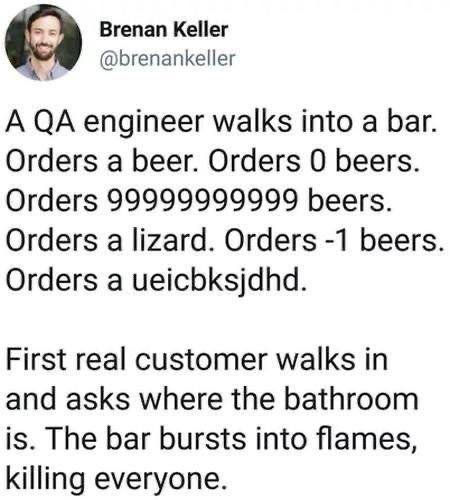

In [29]:
Image('photo_2025-10-31_23-23-10.jpg')